In [1]:
%pip install --upgrade scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
import joblib
import pickle
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [3]:
filePath = '../../data/processed/engineered_betting_features.csv'
df = pd.read_csv(filePath)
df

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,B365H,B365D,B365A,B365>2.5,B365<2.5,B365AHH,B365AHA,B365AH,VCH,VCD,VCA,BSH,BSD,BSA,BWH,BWD,BWA,GBH,GBD,GBA,GB>2.5,GB<2.5,GBAHH,GBAHA,GBAH,IWH,IWD,IWA,LBH,LBD,LBA,LBAHH,LBAHA,LBAH,PSH,PSD,PSA,P>2.5,P<2.5,PAHH,PAHA,SOH,SOD,SOA,SBH,SBD,SBA,SJH,SJD,SJA,WHH,WHD,WHA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,MaxAHH,MaxAHA,AvgAHH,AvgAHA,AHh,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,BTTS,Home_2plus,Away_2plus,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,h2h_home_wins_last5,home_league_position,away_league_position,position_diff,HomePts,AwayPts,HomeGoalDiff,AwayGoalDiff,HomeRecentGoalDiff,AwayRecentGoalDiff,RecentGoalDiff,HomeRecentShotsOnTarget,AwayRecentShotsOnTarget,RecentShotsOnTargetDiff,PosDiff,B365>2.5_missing,B365<2.5_missing,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,EarlySeason,RefereeAggression,B365H_prob,B365D_prob,B365A_prob,B365H_prob_norm,B365D_prob_norm,B365A_prob_norm,cons_mean_home,cons_mean_draw,cons_mean_away,cons_min_home,cons_min_draw,cons_min_away,cons_max_home,cons_max_draw,cons_max_away,home_odds_spread,draw_odds_spread,away_odds_spread,B365_overround,cons_overround,cons_mean_over2.5,cons_mean_under2.5,cons_over2.5_prob,cons_under2.5_prob,mean_AH_home,mean_AH_away,market_AHh,target_home_plus_two,target_away_plus_two,home_away_odds_ratio
0,2002-08-27,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.17,5.50,13.00,1.867394,2.013934,1.953053,1.950898,-0.336141,2.850784,4.027811,4.935736,2.624982,3.753932,4.749475,2.732814,3.917273,4.548528,1.150000,6.500000,12.000000,1.847198,1.837633,1.89003,1.914697,-0.323485,1.20,5.00,10.00,1.200000,5.000000,11.000000,1.931357,1.914883,-0.349454,2.958986,4.266214,4.992703,1.856226,2.157956,1.967555,1.955565,1.18000,6.000000,13.000000,1.170000,5.500000,13.000000,2.619415,3.778735,4.686697,1.16,5.50,12.00,41.0,2.940935,2.722174,4.173095,3.880495,5.45658,4.757603,36.5166,2.003017,1.902307,2.033331,1.930361,23.13209,-0.303451,2.004782,1.93259,2.173407,2.071169,3.1928,4.493388,5.08369,3.003213,4.243009,4.610582,1.890303,2.207561,1.821665,2.


=== Evaluating target_home_plus_two ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.64      0.75      0.69       876
           1       0.60      0.48      0.54       705

    accuracy                           0.63      1581
   macro avg       0.62      0.61      0.61      1581
weighted avg       0.62      0.63      0.62      1581


Best threshold for F1: 0.250
F1-score at best threshold: 0.628
Precision at best threshold: 0.473
Recall at best threshold: 0.932

Classification report (best F1 threshold):
              precision    recall  f1-score   support

           0       0.75      0.16      0.27       876
           1       0.47      0.93      0.63       705

    accuracy                           0.51      1581
   macro avg       0.61      0.55      0.45      1581
weighted avg       0.63      0.51      0.43      1581



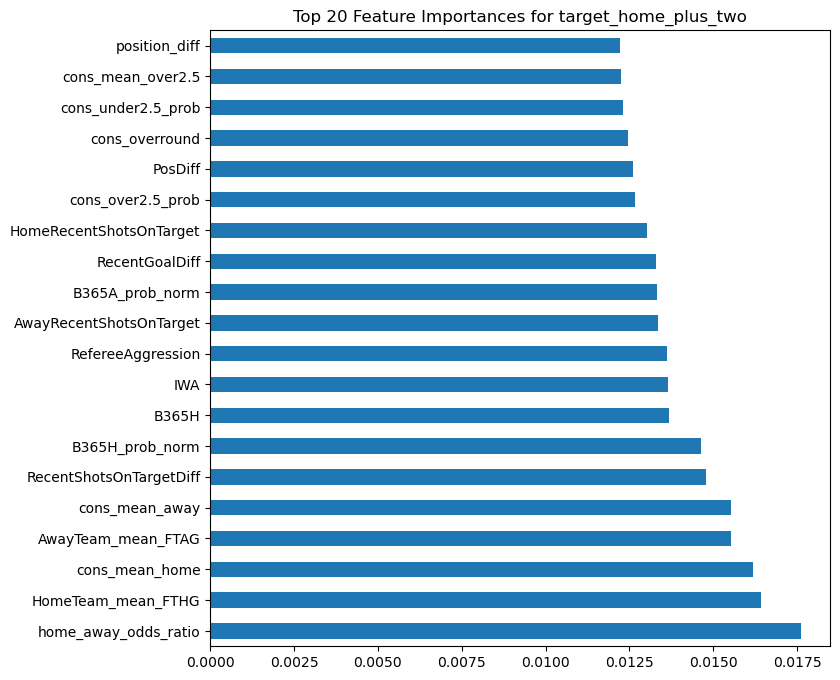

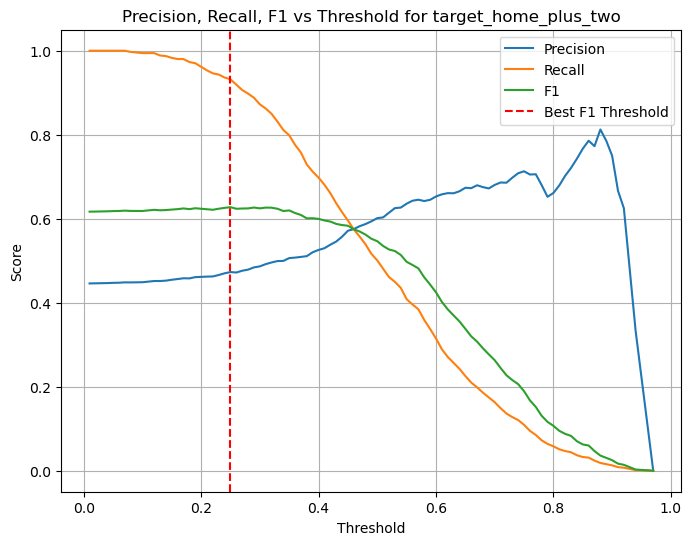


=== Evaluating target_away_plus_two ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.71      0.89      0.79      1075
           1       0.50      0.24      0.33       506

    accuracy                           0.68      1581
   macro avg       0.61      0.56      0.56      1581
weighted avg       0.64      0.68      0.64      1581


Best threshold for F1: 0.260
F1-score at best threshold: 0.509
Precision at best threshold: 0.381
Recall at best threshold: 0.769

Classification report (best F1 threshold):
              precision    recall  f1-score   support

           0       0.79      0.41      0.54      1075
           1       0.38      0.77      0.51       506

    accuracy                           0.53      1581
   macro avg       0.59      0.59      0.53      1581
weighted avg       0.66      0.53      0.53      1581



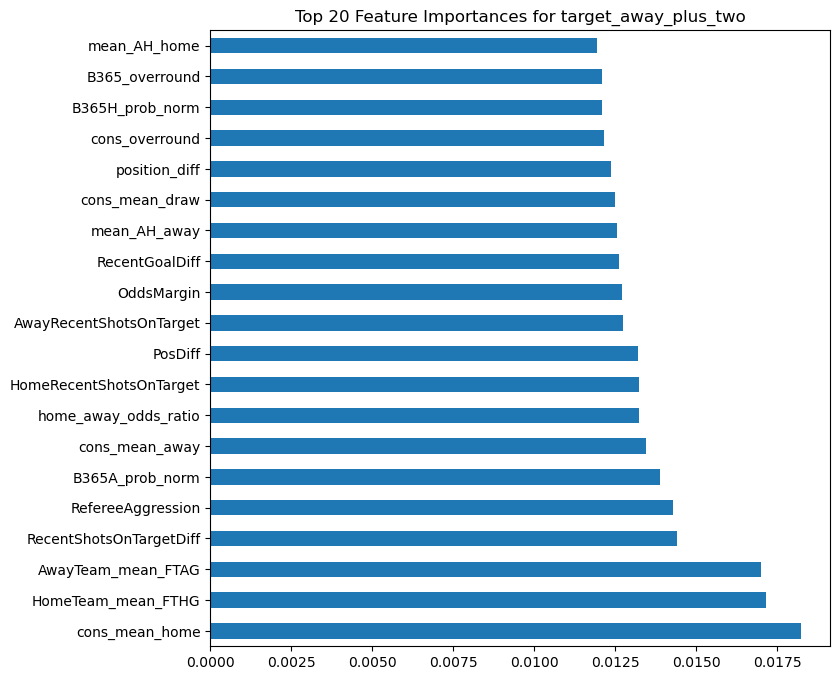

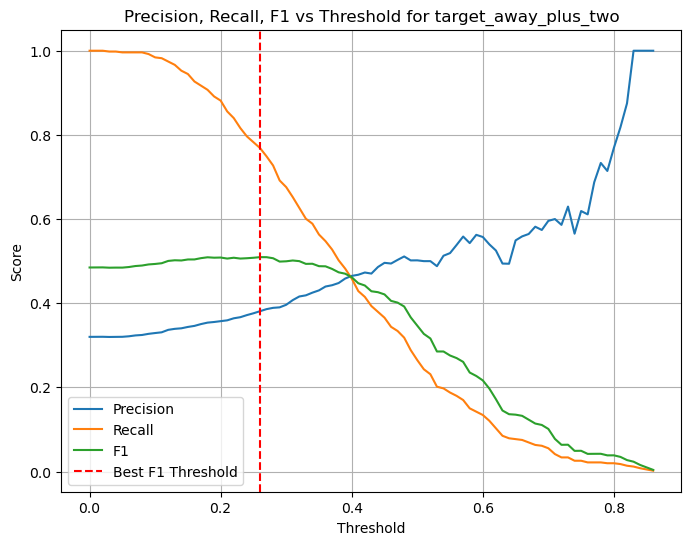

In [9]:

cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',
    'HC', 'AC',
    'HF', 'AF',
    'HY', 'AY',
    'HR', 'AR',
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Home_2plus', 'Away_2plus',
    'target_home_plus_two', 'target_away_plus_two'
]

for target_col in ['target_home_plus_two', 'target_away_plus_two']:
    print(f"\n=== Evaluating {target_col} ===")
    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    # Standard classification report (using default threshold 0.5)
    y_pred = rf.predict(X_test)
    print("Classification report (threshold=0.5):")
    print(classification_report(y_test, y_pred))

    # --- Find best threshold for F1 ---
    y_probs = rf.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1[:-1])  # thresholds is shorter by 1 than precision/recall
    best_threshold = thresholds[best_idx]
    print(f"\nBest threshold for F1: {best_threshold:.3f}")
    print(f"F1-score at best threshold: {f1[best_idx]:.3f}")
    print(f"Precision at best threshold: {precision[best_idx]:.3f}")
    print(f"Recall at best threshold: {recall[best_idx]:.3f}")

    # Show classification report at best threshold
    y_pred_best = (y_probs >= best_threshold).astype(int)
    print("\nClassification report (best F1 threshold):")
    print(classification_report(y_test, y_pred_best))

    # --- Feature Importances ---
    feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
    feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
    plt.title(f'Top 20 Feature Importances for {target_col}')
    plt.show()

    # --- Plot metrics vs threshold ---
    plt.figure(figsize=(8,6))
    plt.plot(thresholds, precision[:-1], label='Precision')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.plot(thresholds, f1[:-1], label='F1')
    plt.axvline(best_threshold, color='r', linestyle='--', label='Best F1 Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Precision, Recall, F1 vs Threshold for {target_col}')
    plt.legend()
    plt.grid()
    plt.show()